## Project Overview
- **Objective**: Predict mining quality (e.g., ore grade) using machine learning.
- **Dataset**: Description of the dataset used (source, features, target variable).
- **Key Steps**: Data loading, cleaning, exploratory analysis, modeling, and evaluation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from matplotlib.pyplot import figure
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score,  root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge

### Load Data

- Description: File path, sample rows, and dataset shape.

In [2]:
df = pd.read_csv("data/mining_quality/MiningProcess_Flotation_Plant_Database.csv")
df.head(3)

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"


In [3]:
df.shape

(737453, 24)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   date                          737453 non-null  str  
 1   % Iron Feed                   737453 non-null  str  
 2   % Silica Feed                 737453 non-null  str  
 3   Starch Flow                   737453 non-null  str  
 4   Amina Flow                    737453 non-null  str  
 5   Ore Pulp Flow                 737453 non-null  str  
 6   Ore Pulp pH                   737453 non-null  str  
 7   Ore Pulp Density              737453 non-null  str  
 8   Flotation Column 01 Air Flow  737453 non-null  str  
 9   Flotation Column 02 Air Flow  737453 non-null  str  
 10  Flotation Column 03 Air Flow  737453 non-null  str  
 11  Flotation Column 04 Air Flow  737453 non-null  str  
 12  Flotation Column 05 Air Flow  737453 non-null  str  
 13  Flotation Column 06 Air F

### Data Cleaning

- Steps taken: drop duplicates, check for missing values, fix types, convert commas to dots.

In [5]:
df = df.drop(columns=["date"])

In [6]:
df.isnull().sum()

% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1171)

In [8]:
df = df.drop_duplicates()

In [9]:
df = df.replace(",", ".", regex=True)

In [10]:
df.head(1)

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.37,523.344,66.91,1.31


In [ ]:
df = df.apply(pd.to_numeric, errors="coerce").astype(np.float32).round(3)
df.dtypes

% Iron Feed                     float32
% Silica Feed                   float32
Starch Flow                     float32
Amina Flow                      float32
Ore Pulp Flow                   float32
Ore Pulp pH                     float32
Ore Pulp Density                float32
Flotation Column 01 Air Flow    float32
Flotation Column 02 Air Flow    float32
Flotation Column 03 Air Flow    float32
Flotation Column 04 Air Flow    float32
Flotation Column 05 Air Flow    float32
Flotation Column 06 Air Flow    float32
Flotation Column 07 Air Flow    float32
Flotation Column 01 Level       float32
Flotation Column 02 Level       float32
Flotation Column 03 Level       float32
Flotation Column 04 Level       float32
Flotation Column 05 Level       float32
Flotation Column 06 Level       float32
Flotation Column 07 Level       float32
% Iron Concentrate              float32
% Silica Concentrate            float32
dtype: object

### Correlation & Multicollinearity
- Correlation heatmap, columns removed for high correlation (threshold).

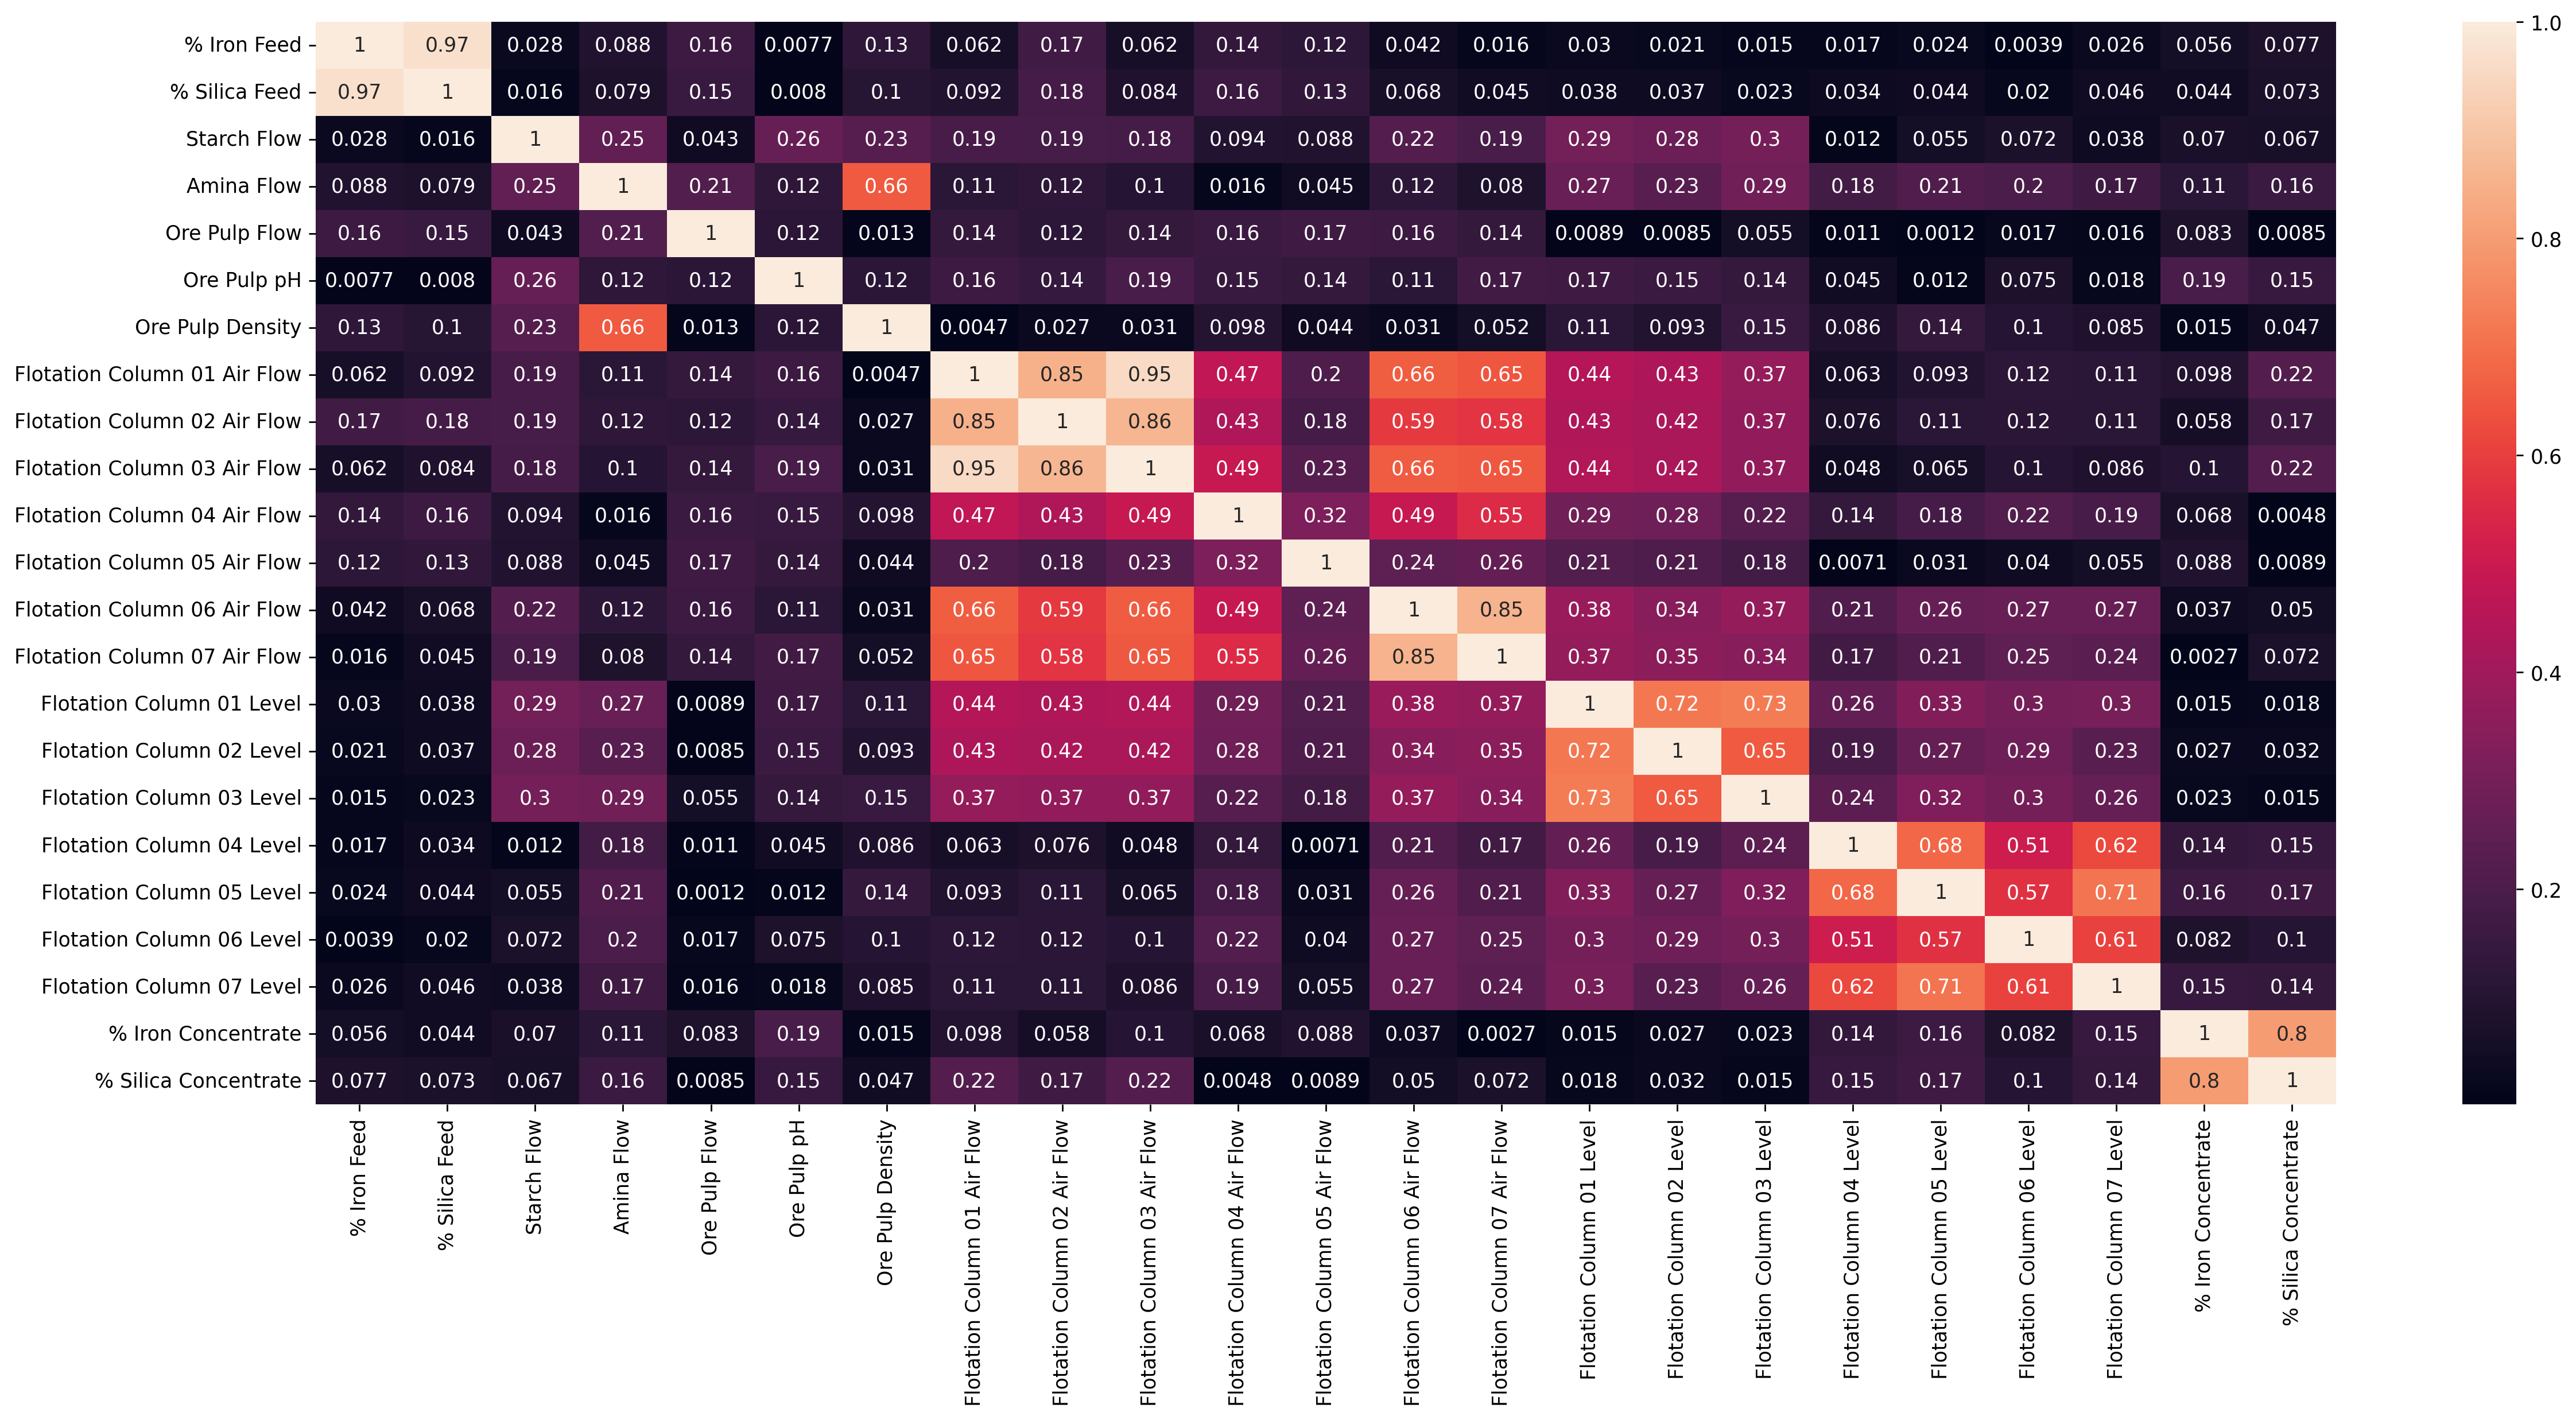

In [12]:
corr = df.corr().abs()
figure(figsize=(20, 10), dpi=250)
sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.show()

In [ ]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

threshold = 0.9

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df = df.drop(columns=to_drop)
df = df.drop(columns=["% Iron Concentrate"]) 

print("Dropping", len(to_drop)+1, "columns")

Dropping 3 columns


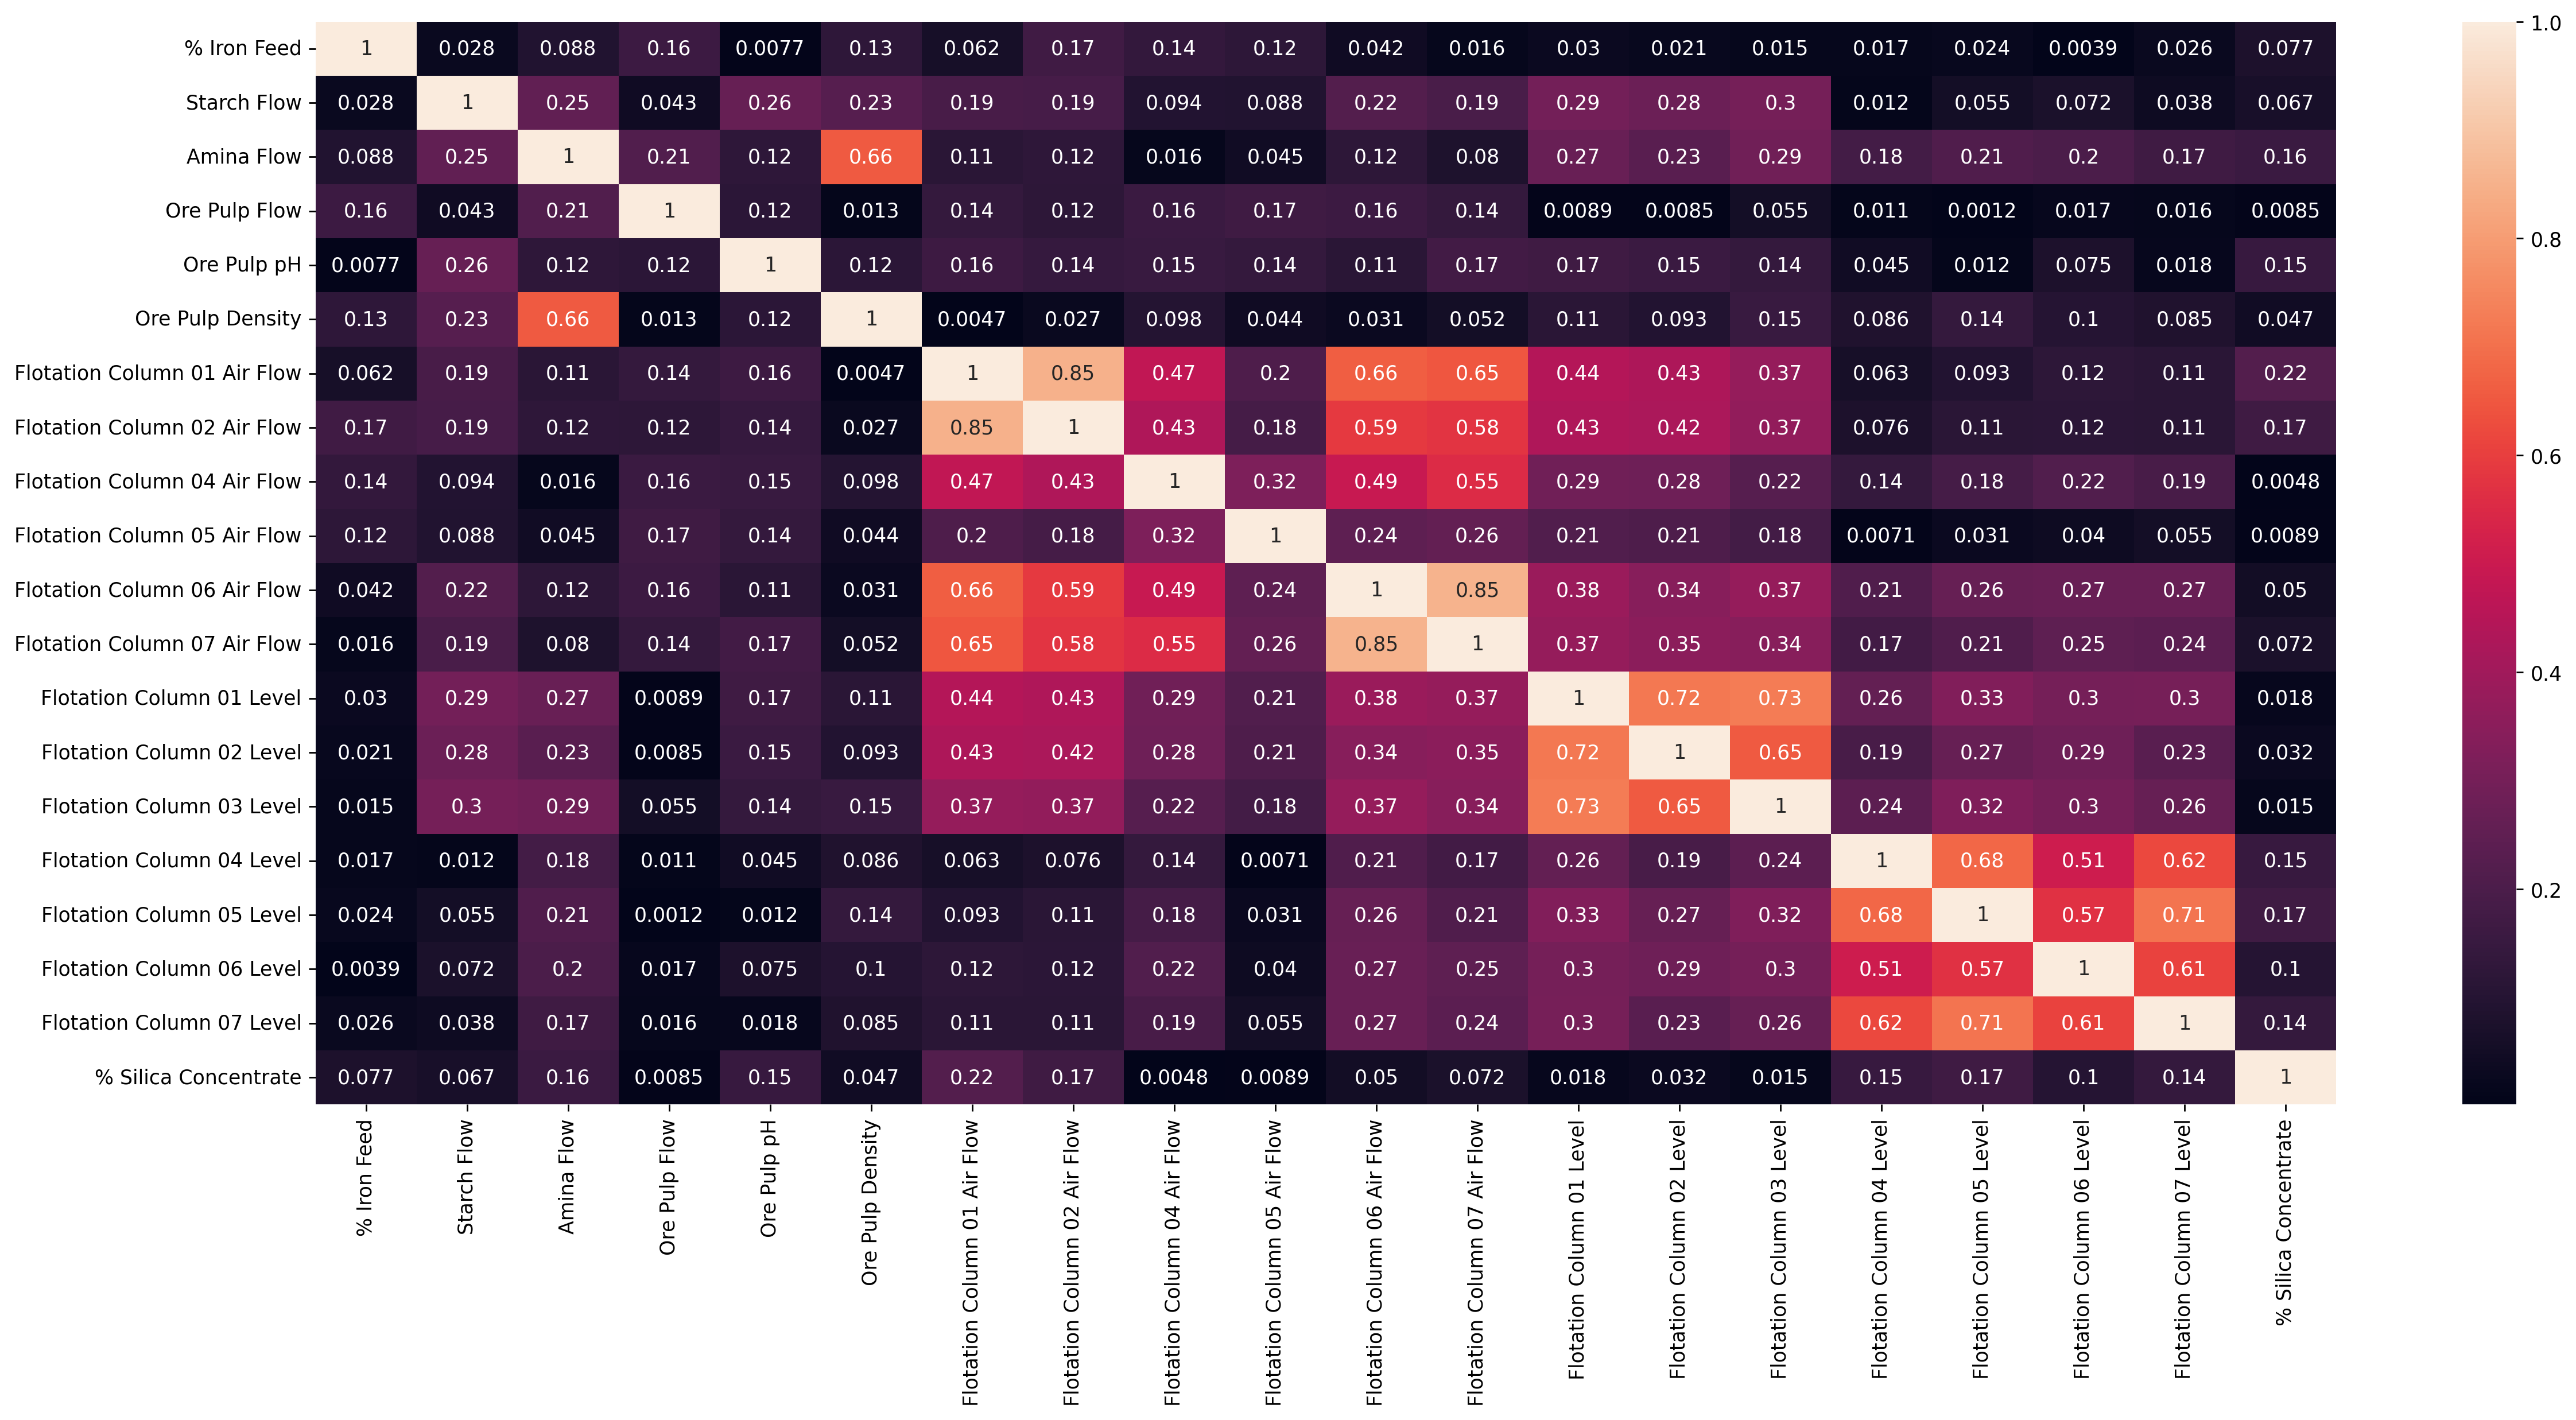

In [14]:
corr = df.corr().abs()
figure(figsize=(20, 10), dpi=250)
sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=["% Silica Concentrate"])
y = df["% Silica Concentrate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

In [ ]:
print("Train R2: ", round(rf.score(X_train, y_train), 4))
print("Test R2: ", round(rf.score(X_test, y_test), 4))

Train R2: 0.9944
Test R2 : 0.9608


[]

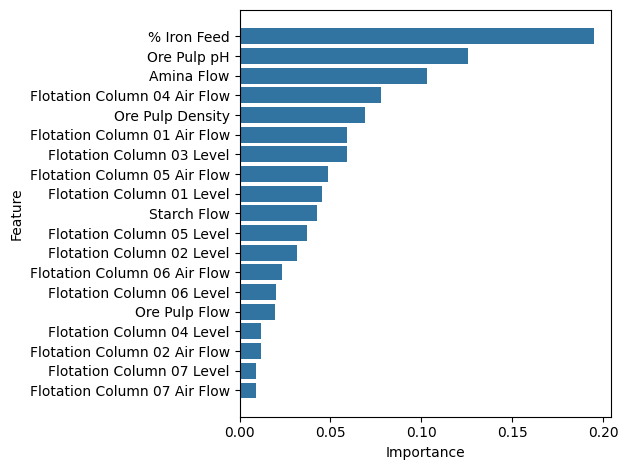

In [ ]:
feature_importance_df = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(data=feature_importance_df, x="Importance", y="Feature", orient="h")
plt.tight_layout()
plt.plot()

### Modeling
Models evaluated (Linear, Ridge, RandomForest, GradientBoosting) and training procedure.

In [ ]:
attributes_to_keep = feature_importance_df.head(12)["Feature"].tolist()

X_sel = X[attributes_to_keep]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sel, y, test_size=0.3, random_state=42)

In [ ]:
rf_sel = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sel.fit(X_train_s, y_train_s)  

In [ ]:
print("Train R2: ", round(rf_sel.score(X_train_s, y_train_s), 4))
print("Test R2: ", round(rf_sel.score(X_test_s, y_test_s), 4))

Train R2: 0.9945
Test R2 : 0.9622


### Model Comparison
Table of final metrics (R2, RMSE, MAE) per model and short interpretation of results.

In [ ]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, solver="sag"),
    "RandomForest": rf_sel,
    "GradientBoost": GradientBoostingRegressor(random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    if model is rf_sel:
        y_pred = model.predict(X_test_s)
    else:
        model.fit(X_train_s, y_train_s)
        y_pred = model.predict(X_test_s)
        
    predictions[name] = y_pred

    r2 = r2_score(y_test_s, y_pred)
    rmse = root_mean_squared_error(y_test_s, y_pred)
    mae = mean_absolute_error(y_test_s, y_pred)

    results.append({
        "Model": name,
        "R2": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,Model,R2,RMSE,MAE
2,RandomForest,0.9622,0.2185,0.0872
3,GradientBoost,0.3399,0.9137,0.7131
1,Ridge,0.1287,1.0498,0.8340
0,Linear,0.0672,1.0862,0.8708


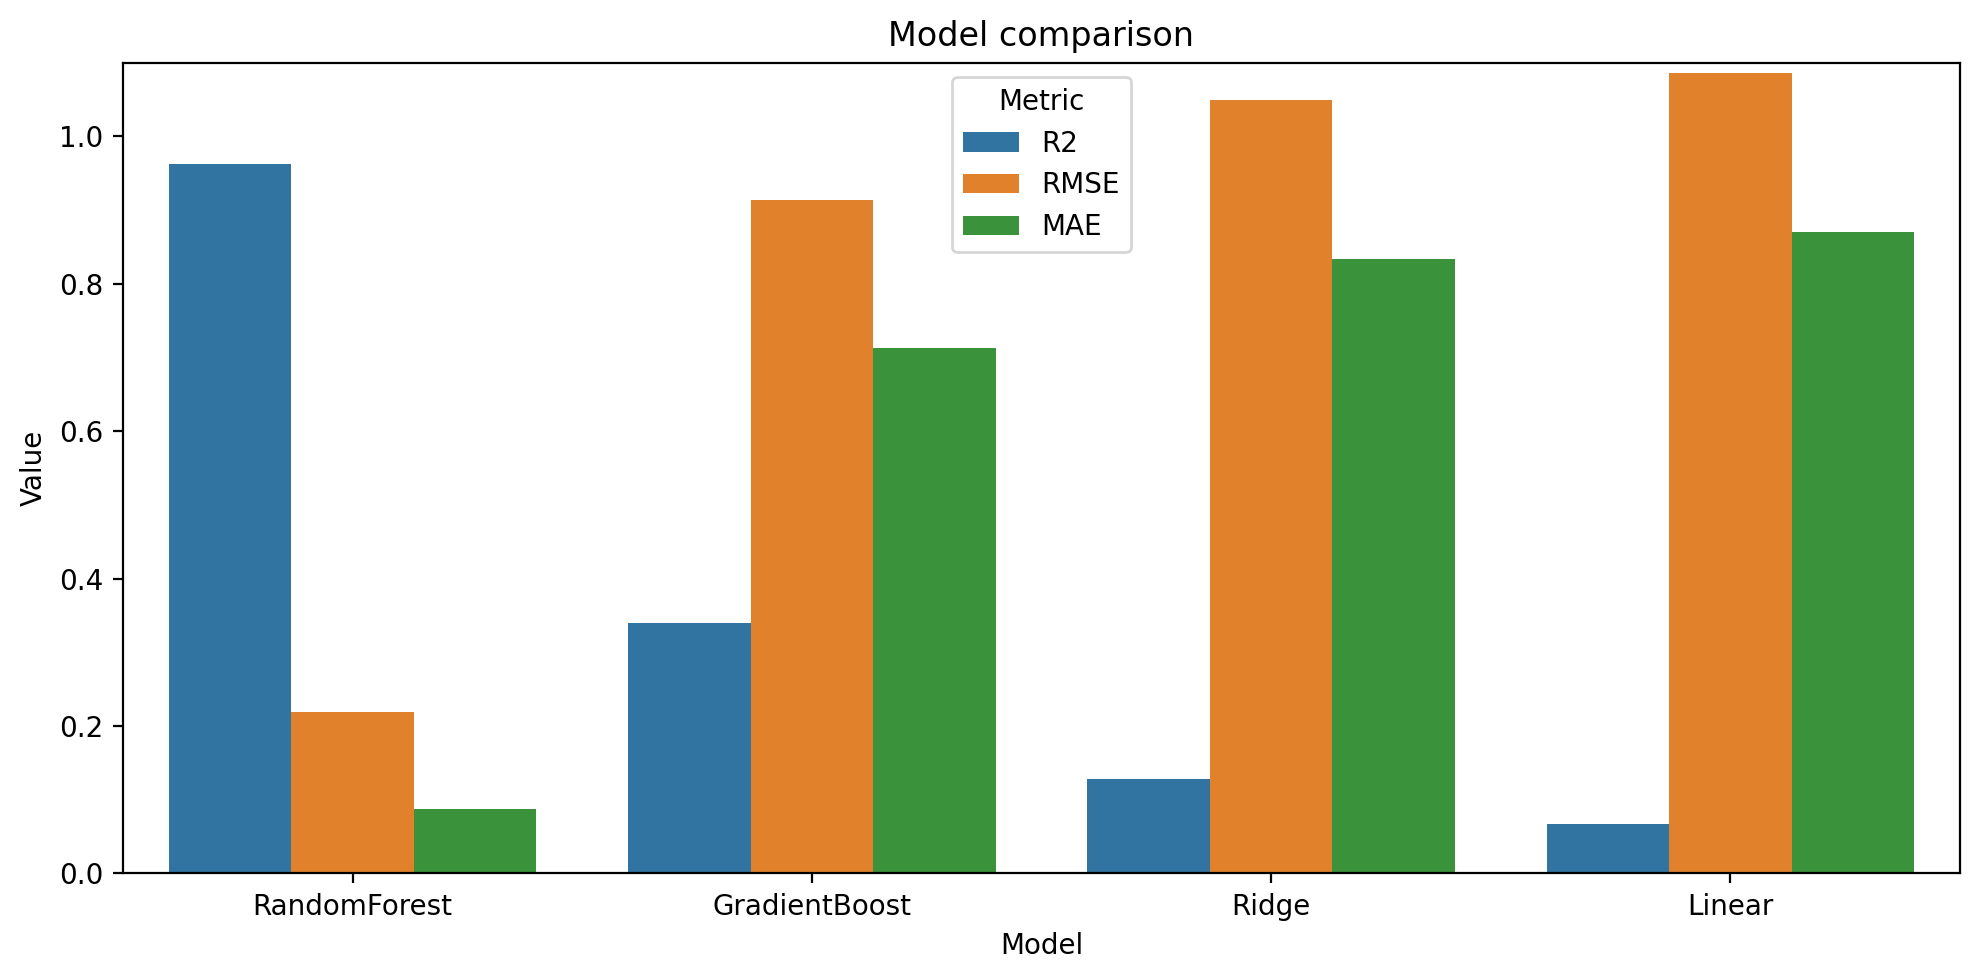

In [30]:
metrics = results_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5), dpi=200)
sns.barplot(data=metrics, x='Model', y='Value', hue='Metric')
plt.ylim(0, 1.1)
plt.title('Model comparison')
plt.tight_layout()
plt.show()

### Cross Validation

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    r2_scores  = cross_val_score(model, X_train_s, y_train_s, scoring="r2", cv=cv)
    rmse_scores = -cross_val_score(model, X_train_s, y_train_s, scoring="neg_root_mean_squared_error", cv=cv)
    mae_scores  = -cross_val_score(model, X_train_s, y_train_s, scoring="neg_mean_absolute_error", cv=cv)

    cv_results.append({
        "Model": name,
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std(),
        "CV_MAE_mean": mae_scores.mean(),
        "CV_MAE_std": mae_scores.std()
    })

pd.DataFrame(cv_results).sort_values("CV_R2_mean", ascending=False)

,Model,CV_R2_mean,CV_R2_std,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std
2,RandomForest,0.953951,0.000652,0.241630,0.001660,0.102074,0.000923
3,GradientBoost,0.345682,0.000688,0.910853,0.002022,0.710996,0.001828
1,Ridge,0.128987,0.001588,1.050930,0.002857,0.835413,0.002183
0,Linear,0.065002,0.001018,1.088829,0.003021,0.873035,0.002120
